In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

In [14]:
import pandas as pd

columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

df = pd.read_csv("KDDTrain+.txt", names=columns)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [15]:
print("Dataset shape:", df.shape)

print("\nLabel counts:")
print(df["label"].value_counts().head(10))

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (125973, 43)

Label counts:
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64

Missing values:
0


In [16]:
df["label"] = df["label"].apply(lambda x: "normal" if x == "normal" else "attack")

print(df["label"].value_counts())

label
normal    67343
attack    58630
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = ["protocol_type", "service", "flag"]

encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,1,20,9,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1,20
1,0,2,44,9,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1,15
2,0,1,49,5,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0,19
3,0,1,24,9,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1,21
4,0,1,24,9,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1,21


In [18]:
X = df.drop(["label", "difficulty"], axis=1)
y = df["label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (125973, 41)
Target shape: (125973,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 94479
Testing samples: 31494


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy:", log_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

print("\nClassification Report:")
print(classification_report(y_test, log_predictions, target_names=label_encoder.classes_))

Logistic Regression Accuracy: 0.9538324760271798

Confusion Matrix:
[[13799   859]
 [  595 16241]]

Classification Report:
              precision    recall  f1-score   support

      attack       0.96      0.94      0.95     14658
      normal       0.95      0.96      0.96     16836

    accuracy                           0.95     31494
   macro avg       0.95      0.95      0.95     31494
weighted avg       0.95      0.95      0.95     31494



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions, target_names=label_encoder.classes_))

Random Forest Accuracy: 0.9989521813678796

Confusion Matrix:
[[14634    24]
 [    9 16827]]

Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     14658
      normal       1.00      1.00      1.00     16836

    accuracy                           1.00     31494
   macro avg       1.00      1.00      1.00     31494
weighted avg       1.00      1.00      1.00     31494



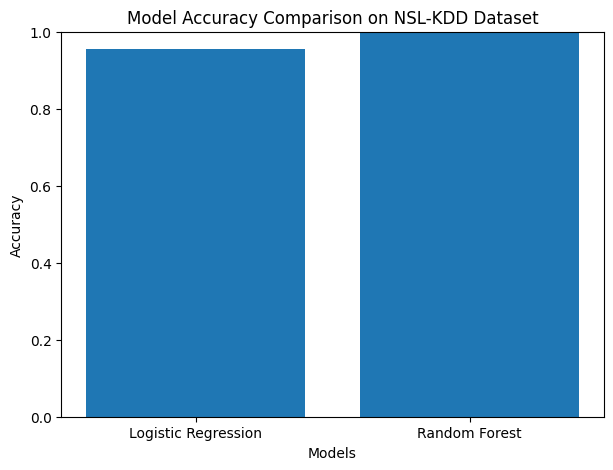

In [23]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
accuracies = [log_accuracy, rf_accuracy]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison on NSL-KDD Dataset")
plt.ylim(0, 1)
plt.show()

In [25]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)
result = label_encoder.inverse_transform(prediction)

print("Predicted Class:", result[0])

actual = label_encoder.inverse_transform([y_test.iloc[0]])
print("Actual Class:", actual[0])

Predicted Class: attack
Actual Class: attack
